 ## Random Forest

Modelo de clasificación binaria para predecir si la MTA publicará una alerta oficial
en los próximos 30 minutos para una línea concreta.



## 0) Setup

In [3]:
import os
import sys
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
    ConfusionMatrixDisplay
)

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_context('notebook')
plt.rcParams['figure.figsize'] = (14, 5)

PROJECT_ROOT = Path.cwd().parent.parent.parent
sys.path.insert(0, str(PROJECT_ROOT))
from src.common.minio_client import download_df_parquet


TARGET_COL = "alert_in_next_30m"
RANDOM_STATE = 42

# Columnas categóricas que necesitan encoding para sklearn
CAT_COLS = ['route_id', 'direction', 'tipo_referente']

print("✓ Setup completado")

✓ Setup completado


## 1) Carga de datos desde MinIO

In [5]:
access_key = os.getenv("MINIO_ACCESS_KEY")
secret_key = os.getenv("MINIO_SECRET_KEY")
if not access_key or not secret_key:
    raise ValueError("MINIO_ACCESS_KEY y MINIO_SECRET_KEY deben estar definidas")

print("Cargando datasets desde MinIO...")


MINIO_PATH_FEB = "grupo5/final/year=2025/month=02/dataset_final.parquet"


df_febrero = download_df_parquet(access_key, secret_key, MINIO_PATH_FEB)

df = df_febrero

#print(f"\n✓ Enero:   {df_enero.shape[0]:,} filas")
print(f"✓ Febrero: {df_febrero.shape[0]:,} filas")
print(f"✓ Total:   {df.shape[0]:,} filas × {df.shape[1]} columnas")

Cargando datasets desde MinIO...
✓ Febrero: 5,683,208 filas
✓ Total:   5,683,208 filas × 47 columnas


## 2)

Esperamos un desbalance muy marcado: la mayoría de observaciones son momentos normales.

Distribución de 'alert_in_next_30m':
  Normal     (0): 4,808,698  (84.61%)
  Pre-alerta (1):   874,510  (15.39%)
  Ratio desbalance: 5:1

→ Usaremos class_weight='balanced' para compensar el desbalance


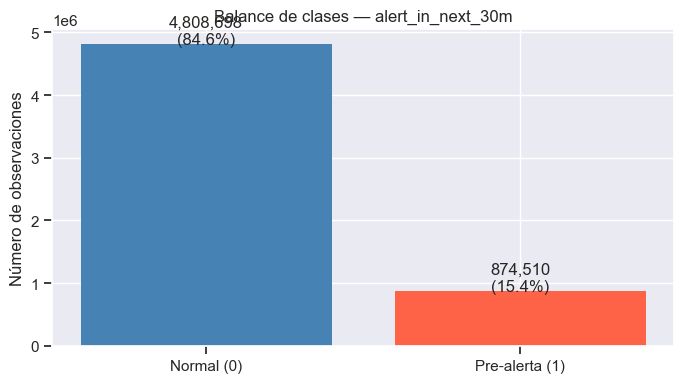

In [7]:
# Distribución del target
vc = df[TARGET_COL].value_counts()
ratio = vc[0] / vc[1]

print(f"Distribución de '{TARGET_COL}':")
print(f"  Normal     (0): {vc[0]:>9,}  ({vc[0]/len(df)*100:.2f}%)")
print(f"  Pre-alerta (1): {vc[1]:>9,}  ({vc[1]/len(df)*100:.2f}%)")
print(f"  Ratio desbalance: {ratio:.0f}:1")
print(f"\n→ Usaremos class_weight='balanced' para compensar el desbalance")

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(["Normal (0)", "Pre-alerta (1)"], vc.values, color=["steelblue", "tomato"])
ax.set_title(f"Balance de clases — {TARGET_COL}")
ax.set_ylabel("Número de observaciones")
for i, v in enumerate(vc.values):
    ax.text(i, v + len(df)*0.001, f"{v:,}\n({v/len(df)*100:.1f}%)", ha="center")
plt.tight_layout()
plt.show()

## 3) Selección de features y encoding

Usamos las mismas 21 variables que `tecnica_XGBoost.ipynb` para que los resultados
sean comparables directamente.

A diferencia de XGBoost, **Random Forest de sklearn necesita que las variables
categóricas sean numéricas**. Aplicamos `LabelEncoder` a `route_id`, `direction`
y `tipo_referente`.

In [14]:
ventana = 4
df['headway_rolling_std'] = df.groupby('stop_id')['actual_headway_seconds']\
    .transform(lambda x: x.rolling(ventana, min_periods=1).std())

# Máximo delay reciente: detecta si algún tren cercano lleva retraso severo
df['delay_rolling_max'] = df.groupby('stop_id')['delay_seconds']\
    .transform(lambda x: x.rolling(ventana, min_periods=1).max())

# Aceleración del retraso: si el retraso está creciendo rápido es señal de problema
df['delay_aceleracion'] = df.groupby('stop_id')['delay_seconds']\
    .transform(lambda x: x.diff())
FEATURE_COLS = [
    # Features originales
    'delay_seconds', 'lagged_delay_1', 'lagged_delay_2',
    'route_rolling_delay', 'actual_headway_seconds',
    'is_unscheduled', 'num_updates', 'scheduled_time_to_end',
    'stops_to_end', 'direction',
    'hour_sin', 'hour_cos', 'dow', 'is_weekend',
    'n_eventos_afectando', 'tipo_referente',
    'afecta_previo', 'afecta_durante', 'afecta_despues',
    'temp_extreme',
    # Feature de historial de alertas
    'seconds_since_last_alert',
    # Features de ventana deslizante (nuevas)
    'headway_rolling_std',   # irregularidad del intervalo entre trenes
    'delay_rolling_max',     # peor retraso reciente en la parada
    'delay_aceleracion',     # ritmo al que crece el retraso
]

# Verificar que todas las features existen en el dataset
missing = [c for c in FEATURE_COLS if c not in df.columns]
if missing:
    print(f"⚠️  Columnas no encontradas: {missing}")
    FEATURE_COLS = [c for c in FEATURE_COLS if c in df.columns]
    print(f"   Continuando con {len(FEATURE_COLS)} features")
else:
    print(f"✓ Las {len(FEATURE_COLS)} features están disponibles")

# Ordenar por tiempo (crítico para split temporal)
df['merge_time'] = pd.to_datetime(df['merge_time'])
df = df.sort_values('merge_time').reset_index(drop=True)

# Eliminar filas sin target
df = df.dropna(subset=[TARGET_COL]).copy()
df[TARGET_COL] = df[TARGET_COL].astype(int)

# LabelEncoder para categóricas
encoders = {}
for col in CAT_COLS:
    if col in df.columns:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col].astype(str).fillna('UNKNOWN'))
        encoders[col] = le
        print(f"  Encoded '{col}': {len(le.classes_)} categorías")

# Rellenar NaN en features numéricas con la mediana
df[FEATURE_COLS] = df[FEATURE_COLS].fillna(df[FEATURE_COLS].median(numeric_only=True))

print(f"\nDataset listo: {len(df):,} filas")

C:\Users\david\AppData\Local\Temp\ipykernel_20164\3775914131.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df['headway_rolling_std'] = df.groupby('stop_id')['actual_headway_seconds']\
C:\Users\david\AppData\Local\Temp\ipykernel_20164\3775914131.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df['delay_rolling_max'] = df.groupby('stop_id')['delay_seconds']\
C:\Users\david\AppData\Local\Temp\ipykernel_20164\3775914131.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=Tr

✓ Las 24 features están disponibles
  Encoded 'route_id': 32 categorías
  Encoded 'direction': 2 categorías
  Encoded 'tipo_referente': 6 categorías

Dataset listo: 5,683,208 filas


#### Aquí lo que se hace es, basada la idea en este artículo : https://pub.towardsai.net/can-you-predict-a-subway-delay-before-transit-officials-announce-it-ec16cab64149
Para los alert_in_next_30m = 0 , solo cogen los momentos donde el metro está genuinamente tranquilo (alerta a más de 1 hora o nunca) . Porque si hay una alerta a 45 mins, esa fila tiene alert_in_next_30m = 0, pero el metro en ese momento ya está empezando a fallar pero el target dice que 'normal'. Eso confunde al modelo

In [16]:
mask_positivos = df[TARGET_COL] == 1
mask_negativos_limpios = (
    df['seconds_to_next_alert'].isna() |      
    (df['seconds_to_next_alert'] > 3600)       
)

df = df[mask_positivos | mask_negativos_limpios].copy()
df = df.reset_index(drop=True)

print(f"Dataset tras filtrar negativos ambiguos: {len(df):,} filas")
print(f"  Positivos: {df[TARGET_COL].sum():,} ({df[TARGET_COL].mean()*100:.1f}%)")
print(f"  Negativos: {(df[TARGET_COL]==0).sum():,} ({(df[TARGET_COL]==0).mean()*100:.1f}%)")

Dataset tras filtrar negativos ambiguos: 5,145,528 filas
  Positivos: 874,510 (17.0%)
  Negativos: 4,271,018 (83.0%)


## 4) Split  70 / 15 / 15



In [18]:
n = len(df)
i_train = int(n * 0.70)
i_val   = int(n * 0.85)

df_train = df.iloc[:i_train]
df_val   = df.iloc[i_train:i_val]
df_test  = df.iloc[i_val:]

X_train, y_train = df_train[FEATURE_COLS], df_train[TARGET_COL]
X_val,   y_val   = df_val[FEATURE_COLS],   df_val[TARGET_COL]
X_test,  y_test  = df_test[FEATURE_COLS],  df_test[TARGET_COL]

for name, subset, y in [("Train", df_train, y_train),
                         ("Val",   df_val,   y_val),
                         ("Test",  df_test,  y_test)]:
    pos = y.sum()
    print(f"{name:5s}: {len(subset):>9,} obs | pre-alerta: {pos:>6,} ({pos/len(subset)*100:.2f}%) "
          f"| {subset['merge_time'].min().date()} → {subset['merge_time'].max().date()}")

Train: 3,601,869 obs | pre-alerta: 666,446 (18.50%) | 2025-02-01 → 2025-02-20
Val  :   771,829 obs | pre-alerta: 120,298 (15.59%) | 2025-02-20 → 2025-02-25
Test :   771,830 obs | pre-alerta: 87,766 (11.37%) | 2025-02-25 → 2025-02-28


## 5) Entrenamiento del Random Forest

Parámetros clave:
- class_weight='balanced` — compensa el desbalance 99:1 automáticamente
- max_depth=15 — limitar la profundidad reduce el tiempo de entrenamiento y el sobreajuste
- min_samples_leaf=50 — cada hoja necesita al menos 50 observaciones (evita sobreajuste)
- n_jobs=-1 — usa todos los núcleos disponibles en paralelo

In [20]:
import time

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_leaf=50,
    class_weight='balanced',
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=1
)

print("Entrenando Random Forest...")
t0 = time.time()
rf.fit(X_train, y_train)
elapsed = time.time() - t0

print(f"\n✓ Entrenamiento completado en {elapsed/60:.1f} minutos")

Entrenando Random Forest...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:  1.7min
[Parallel(n_jobs=-1)]: Done 176 tasks      | elapsed:  9.0min



✓ Entrenamiento completado en 10.0 minutos


[Parallel(n_jobs=-1)]: Done 200 out of 200 | elapsed: 10.0min finished


## 6) Evaluación en validación y test

Las métricas importantes son:
- **Recall**: de todas las alertas reales, ¿cuántas detectamos? (no queremos perdernos alertas)
- **Precision**: de lo que predecimos como alerta, ¿cuántas eran reales? (no queremos alarmas falsas)
- **F1**: media armónica de precision y recall
- **AUC-ROC**: capacidad discriminativa general del modelo

In [22]:
def evaluar_modelo(nombre, model, X, y):
    y_pred  = model.predict(X)
    y_proba = model.predict_proba(X)[:, 1]
    return {
        "Modelo":    nombre,
        "Accuracy":  round(accuracy_score(y, y_pred), 4),
        "Precision": round(precision_score(y, y_pred, zero_division=0), 4),
        "Recall":    round(recall_score(y, y_pred, zero_division=0), 4),
        "F1":        round(f1_score(y, y_pred, zero_division=0), 4),
        "AUC-ROC":   round(roc_auc_score(y, y_proba), 4),
    }

res_val  = evaluar_modelo("RF — Validación", rf, X_val, y_val)
res_test = evaluar_modelo("RF — Test",       rf, X_test, y_test)

df_resultados = pd.DataFrame([res_val, res_test]).set_index("Modelo")
print("=== Resultados Random Forest ===")
display(df_resultados)

print("\n=== Reporte detallado (Test) ===")
y_pred_test = rf.predict(X_test)
print(classification_report(y_test, y_pred_test, target_names=["Normal", "Pre-alerta"]))

[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.7s
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:    4.2s
[Parallel(n_jobs=12)]: Done 200 out of 200 | elapsed:    4.7s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.7s
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:    4.2s
[Parallel(n_jobs=12)]: Done 200 out of 200 | elapsed:    4.7s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.6s
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:    4.1s
[Parallel(n_jobs=12)]: Done 200 out of 200 | elapsed:    4.5s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.7s
[Parallel(n_jobs=12)]: Do

=== Resultados Random Forest ===


,Accuracy,Precision,Recall,F1,AUC-ROC
Modelo,,,,,
RF — Validación,0.7569,0.3148,0.4760,0.3790,0.7253
RF — Test,0.7582,0.2461,0.5457,0.3392,0.7712



=== Reporte detallado (Test) ===


[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.6s
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:    4.0s
[Parallel(n_jobs=12)]: Done 200 out of 200 | elapsed:    4.5s finished


              precision    recall  f1-score   support

      Normal       0.93      0.79      0.85    684064
  Pre-alerta       0.25      0.55      0.34     87766

    accuracy                           0.76    771830
   macro avg       0.59      0.67      0.60    771830
weighted avg       0.85      0.76      0.79    771830



## 7) Matriz de confusión

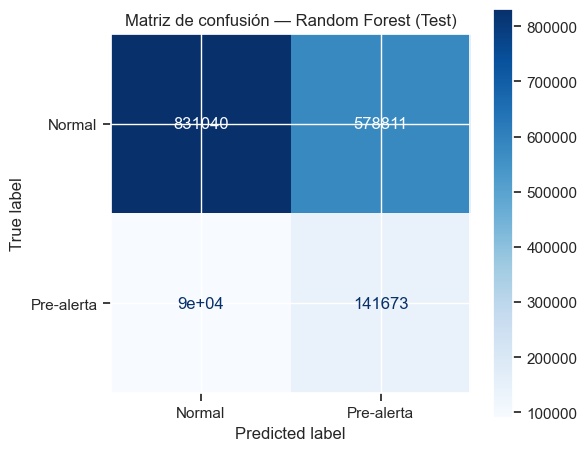

Verdaderos negativos (Normal bien clasificado):    831,040
Falsos positivos (Normal clasificado como alerta): 578,811
Falsos negativos (Alerta no detectada):            89,971  ← los más costosos
Verdaderos positivos (Alerta detectada):           141,673


In [36]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_test,
    display_labels=["Normal", "Pre-alerta"],
    cmap="Blues",
    ax=ax
)
ax.set_title("Matriz de confusión — Random Forest (Test)")
plt.tight_layout()
plt.show()

from sklearn.metrics import confusion_matrix
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_test).ravel()
print(f"Verdaderos negativos (Normal bien clasificado):    {tn:,}")
print(f"Falsos positivos (Normal clasificado como alerta): {fp:,}")
print(f"Falsos negativos (Alerta no detectada):            {fn:,}  ← los más costosos")
print(f"Verdaderos positivos (Alerta detectada):           {tp:,}")

In [30]:
# Ver qué features superan el 2% de importancia
importances = pd.Series(rf.feature_importances_, index=FEATURE_COLS)
features_relevantes = importances_l1[importances_l1 > 0.02].sort_values(ascending=False)

print(f"Features con importancia > 2%: {len(features_relevantes)} de {len(FEATURE_COLS)}")
print()
for feat, imp in features_relevantes.items():
    print(f"  {feat}: {imp:.4f} ({imp*100:.1f}%)")

FEATURE_COLS_REDUCED = features_relevantes.index.tolist()

Features con importancia > 2%: 8 de 24

  seconds_since_last_alert: 0.5441 (54.4%)
  hour_sin: 0.0860 (8.6%)
  hour_cos: 0.0625 (6.2%)
  dow: 0.0585 (5.8%)
  num_updates: 0.0368 (3.7%)
  scheduled_time_to_end: 0.0341 (3.4%)
  delay_rolling_max: 0.0244 (2.4%)
  actual_headway_seconds: 0.0202 (2.0%)


---
# Segunda aproximación — Modelo especializado: Línea 1, año completo 2025

Motivación: el modelo anterior entrena con todas las líneas mezcladas y solo enero.
Esta versión prueba si especializarse en una sola línea con todo el año mejora la precisión,
eliminando el ruido entre líneas y añadiendo variabilidad estacional.

Cambios respecto a la primera aproximación:
- **Datos**: `grupo5/aggregations/lines/line=1/dataset_final.parquet` (enero–diciembre 2025)
- **`route_id` eliminada de features**: valor constante en un modelo de una sola línea
- El resto del pipeline es idéntico para que la comparación sea directa

## A) Carga de datos — Línea 1, año completo

In [59]:
LINEA = "1"
access_key = os.getenv("MINIO_ACCESS_KEY")
secret_key = os.getenv("MINIO_SECRET_KEY")
MINIO_PATH_L1 = f"grupo5/aggregations/lines/line={LINEA}/dataset_final.parquet"

print(f"Cargando dataset línea {LINEA} desde MinIO...")
df2 = download_df_parquet(access_key, secret_key, MINIO_PATH_L1)

print(f"\n✓ Dataset cargado: {df2.shape[0]:,} filas × {df2.shape[1]} columnas")
print(f"  Periodo: {df2['date'].min()} → {df2['date'].max()}")
print(f"  Positivos: {df2[TARGET_COL].sum():,} ({df2[TARGET_COL].mean()*100:.1f}%)")
df2.head(3)


Cargando dataset línea 1 desde MinIO...

✓ Dataset cargado: 5,055,847 filas × 47 columnas
  Periodo: 2025-01-01 → 2025-12-31
  Positivos: 617,514 (12.2%)


,date,match_key,stop_id,route_id,direction,delay_seconds,lagged_delay_1,lagged_delay_2,route_rolling_delay,actual_headway_seconds,...,afecta_durante,afecta_despues,category,num_updates,timestamp_start,seconds_since_last_alert,is_alert_just_published,seconds_to_next_alert,alert_in_next_15m,alert_in_next_30m
0,2025-01-01,000650_1..S03R,101S,1,S,NaN,-12.0,11.0,-43.799999,NaN,...,0,0,None,0.0,NaT,NaN,0,3330.0,0,0
1,2025-01-01,000650_1..S03R,103S,1,S,-20.0,NaN,NaN,NaN,456.0,...,0,0,None,0.0,NaT,NaN,0,3260.0,0,0
2,2025-01-01,000650_1..S03R,104S,1,S,-27.0,-20.0,NaN,-20.000000,456.0,...,0,0,None,0.0,NaT,NaN,0,3177.0,0,0


## B) Features, encoding y filtro de negativos

In [71]:
# ── Preparar merge_time como datetime ────────────────────────────────────────
df2['merge_time'] = pd.to_datetime(df2['merge_time'])

# ── Estadísticos de headway a nivel de LÍNEA (estilo Taggart) ─────────────────
# Taggart calcula mean/max/std del headway sobre toda la línea en ventana de 30 min.
# Como todo el dataset es línea 1, usamos rolling temporal sobre el dataframe completo.
df2 = df2.sort_values('merge_time').reset_index(drop=True)
roll_linea = df2.set_index('merge_time')['actual_headway_seconds'].rolling('30min', min_periods=1)
df2['headway_linea_mean'] = roll_linea.mean().values   # media: ¿cuánto esperan los trenes?
df2['headway_linea_max']  = roll_linea.max().values    # máximo: ¿hay algún tren muy retrasado?
df2['headway_linea_std']  = roll_linea.std().values    # std: ¿los trenes llegan de forma irregular?
df2['headway_ratio']      = df2['actual_headway_seconds'] / (df2['headway_linea_mean'] + 1)
# ratio > 1 → este tren llega más tarde que la media reciente → señal de problema
print("✓ Estadísticos de headway a nivel de línea calculados (estilo Taggart)")

# ── Features de ventana deslizante por parada ─────────────────────────────────
df2 = df2.sort_values(['stop_id', 'merge_time'])
ventana = 4  # ~30 minutos

df2['headway_rolling_std'] = df2.groupby('stop_id', observed=True)['actual_headway_seconds']\
    .transform(lambda x: x.rolling(ventana, min_periods=1).std())
df2['delay_rolling_max'] = df2.groupby('stop_id', observed=True)['delay_seconds']\
    .transform(lambda x: x.rolling(ventana, min_periods=1).max())
df2['delay_aceleracion'] = df2.groupby('stop_id', observed=True)['delay_seconds']\
    .transform(lambda x: x.diff())
print("✓ Features de ventana deslizante por parada calculadas")

# ── Selección de features ─────────────────────────────────────────────────────
FEATURE_COLS_L1 = [
    'delay_seconds', 'lagged_delay_1', 'lagged_delay_2',
    'route_rolling_delay', 'actual_headway_seconds',
    'is_unscheduled', 'num_updates', 'scheduled_time_to_end',
    'stops_to_end', 'direction',
    'hour_sin', 'hour_cos', 'dow', 'is_weekend',
    'n_eventos_afectando', 'tipo_referente',
    'afecta_previo', 'afecta_durante', 'afecta_despues',
    'temp_extreme',
    'seconds_since_last_alert',
    'headway_rolling_std', 'delay_rolling_max', 'delay_aceleracion',
    # Nuevas: headway a nivel de línea completa (estilo Taggart)
    'headway_linea_mean',
    'headway_linea_max',
    'headway_linea_std',
    'headway_ratio',
]

CAT_COLS_L1 = ['direction', 'tipo_referente']

df2 = df2.sort_values('merge_time').reset_index(drop=True)
df2 = df2.dropna(subset=[TARGET_COL]).copy()
df2[TARGET_COL] = df2[TARGET_COL].astype(int)

encoders_l1 = {}
for col in CAT_COLS_L1:
    le = LabelEncoder()
    df2[col] = le.fit_transform(df2[col].astype(str).fillna('UNKNOWN'))
    encoders_l1[col] = le
    print(f"  Encoded '{col}': {len(le.classes_)} categorías")

# Filtro de negativos ambiguos (Taggart 2026)
mask_pos = df2[TARGET_COL] == 1
mask_neg = df2['seconds_to_next_alert'].isna() | (df2['seconds_to_next_alert'] > 3600)
df2 = df2[mask_pos | mask_neg].copy().reset_index(drop=True)

# seconds_since_last_alert: NaN = nunca hubo alerta → valor alto
df2['seconds_since_last_alert'] = df2['seconds_since_last_alert'].fillna(999999)

# Resto de NaN con la mediana
cols_mediana = [c for c in FEATURE_COLS_L1 if c != 'seconds_since_last_alert']
df2[cols_mediana] = df2[cols_mediana].fillna(df2[cols_mediana].median(numeric_only=True))

print(f"\nDataset listo: {len(df2):,} filas")
print(f"  Features totales: {len(FEATURE_COLS_L1)}")
print(f"  Positivos: {df2[TARGET_COL].sum():,} ({df2[TARGET_COL].mean()*100:.1f}%)")
print(f"  Negativos: {(df2[TARGET_COL]==0).sum():,} ({(df2[TARGET_COL]==0).mean()*100:.1f}%)")

✓ Estadísticos de headway a nivel de línea calculados (estilo Taggart)
✓ Features de ventana deslizante por parada calculadas
  Encoded 'direction': 2 categorías
  Encoded 'tipo_referente': 9 categorías

Dataset listo: 4,660,750 filas
  Features totales: 28
  Positivos: 617,514 (13.2%)
  Negativos: 4,043,236 (86.8%)


## C) Split temporal 70 / 15 / 15

In [73]:
n2 = len(df2)
i_train2 = int(n2 * 0.70)
i_val2   = int(n2 * 0.85)

df2_train = df2.iloc[:i_train2]
df2_val   = df2.iloc[i_train2:i_val2]
df2_test  = df2.iloc[i_val2:]

X2_train, y2_train = df2_train[FEATURE_COLS_L1], df2_train[TARGET_COL]
X2_val,   y2_val   = df2_val[FEATURE_COLS_L1],   df2_val[TARGET_COL]
X2_test,  y2_test  = df2_test[FEATURE_COLS_L1],  df2_test[TARGET_COL]

for name, subset, y in [("Train", df2_train, y2_train),
                         ("Val",   df2_val,   y2_val),
                         ("Test",  df2_test,  y2_test)]:
    pos = y.sum()
    print(f"{name:5s}: {len(subset):>9,} obs | pre-alerta: {pos:>6,} ({pos/len(subset)*100:.2f}%) "
          f"| {subset['merge_time'].min().date()} → {subset['merge_time'].max().date()}")

Train: 3,262,525 obs | pre-alerta: 448,541 (13.75%) | 2025-01-01 → 2025-09-15
Val  :   699,112 obs | pre-alerta: 78,849 (11.28%) | 2025-09-15 → 2025-11-06
Test :   699,113 obs | pre-alerta: 90,124 (12.89%) | 2025-11-06 → 2025-12-31


## D) Entrenamiento — Línea 1

In [75]:
import time

rf_l1 = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_leaf=50,
    class_weight={0: 1, 1: 3},  # Antes: 'balanced' (~1:8). Ahora penalizamos
                                  # los falsos negativos x3, pero sin ser tan
                                  # agresivos. Objetivo: subir precisión sacrificando
                                  # un poco de recall.
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=0
)

print("Entrenando Random Forest — Línea 1 (class_weight={0:1, 1:3})...")
t0 = time.time()
rf_l1.fit(X2_train, y2_train)
elapsed = time.time() - t0
print(f"✓ Entrenamiento completado en {elapsed/60:.1f} minutos")

Entrenando Random Forest — Línea 1 (class_weight={0:1, 1:3})...
✓ Entrenamiento completado en 4.4 minutos


## E) Evaluación y comparación con primera aproximación

In [67]:
res_l1_val  = evaluar_modelo("RF L1 — Validación", rf_l1, X2_val,  y2_val)
res_l1_test = evaluar_modelo("RF L1 — Test",       rf_l1, X2_test, y2_test)

# res_test puede no estar definido si se ejecuta solo la Parte 2
try:
    fila_general = {
        "Modelo":    "RF General — Feb 2025 (Test)",
        "Datos":     "Feb 2025, todas las líneas",
        "Precision": res_test["Precision"],
        "Recall":    res_test["Recall"],
        "F1":        res_test["F1"],
        "AUC-ROC":   res_test["AUC-ROC"],
    }
except NameError:
    fila_general = {
        "Modelo":    "RF General — Feb 2025 (Test)",
        "Datos":     "No disponible (ejecuta Parte 1 primero)",
        "Precision": None, "Recall": None, "F1": None, "AUC-ROC": None,
    }

comparacion = pd.DataFrame([
    fila_general,
    {
        "Modelo":    "RF Línea 1 — Año completo (Test)",
        "Datos":     "Ene–Dic 2025, solo línea 1",
        "Precision": res_l1_test["Precision"],
        "Recall":    res_l1_test["Recall"],
        "F1":        res_l1_test["F1"],
        "AUC-ROC":   res_l1_test["AUC-ROC"],
    },
]).set_index("Modelo")

print("=== Comparación de aproximaciones ===")
display(comparacion)

print("\n=== Reporte detallado — Línea 1 (Test) ===")
THRESHOLD = 0.449
y2_proba_test = rf_l1.predict_proba(X2_test)[:, 1]
y2_pred_test = (y2_proba_test >= THRESHOLD).astype(int)
print(f"(Usando threshold = {THRESHOLD})")
print(classification_report(y2_test, y2_pred_test, target_names=["Normal", "Pre-alerta"]))

=== Comparación de aproximaciones ===


,Datos,Precision,Recall,F1,AUC-ROC
Modelo,,,,,
RF General — Feb 2025 (Test),"Feb 2025, todas las líneas",0.2461,0.5457,0.3392,0.7712
RF Línea 1 — Año completo (Test),"Ene–Dic 2025, solo línea 1",0.1375,0.0454,0.0683,0.5475



=== Reporte detallado — Línea 1 (Test) ===
(Usando threshold = 0.449)
              precision    recall  f1-score   support

      Normal       0.87      0.94      0.91    608989
  Pre-alerta       0.14      0.06      0.09     90124

    accuracy                           0.83    699113
   macro avg       0.51      0.50      0.50    699113
weighted avg       0.78      0.83      0.80    699113



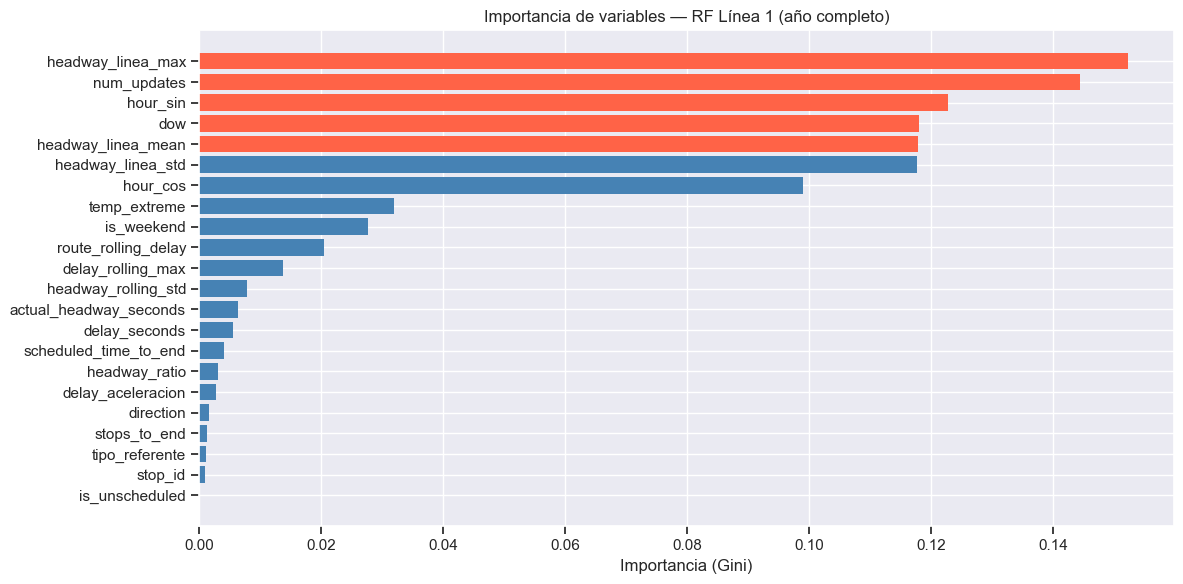

Top 5 variables más predictivas:
  1. headway_linea_max: 0.1521 (15.2%)
  2. num_updates: 0.1443 (14.4%)
  3. hour_sin: 0.1227 (12.3%)
  4. dow: 0.1179 (11.8%)
  5. headway_linea_mean: 0.1178 (11.8%)


In [69]:
importances_l1 = pd.Series(rf_l1.feature_importances_, index=FEATURE_COLS_L1)
importances_l1 = importances_l1.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
colors = ["tomato" if i < 5 else "steelblue" for i in range(len(importances_l1))]
ax.barh(importances_l1.index[::-1], importances_l1.values[::-1], color=colors[::-1])
ax.set_title("Importancia de variables — RF Línea 1 (año completo)")
ax.set_xlabel("Importancia (Gini)")
plt.tight_layout()
plt.show()

print("Top 5 variables más predictivas:")
for i, (feat, imp) in enumerate(importances_l1.head(5).items(), 1):
    print(f"  {i}. {feat}: {imp:.4f} ({imp*100:.1f}%)")

Threshold óptimo (máx F1): 0.449
  Precision: 0.4155
  Recall:    0.3930
  F1:        0.4040


C:\Users\david\AppData\Local\Temp\ipykernel_20164\568056655.py:45: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
C:\Users\david\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


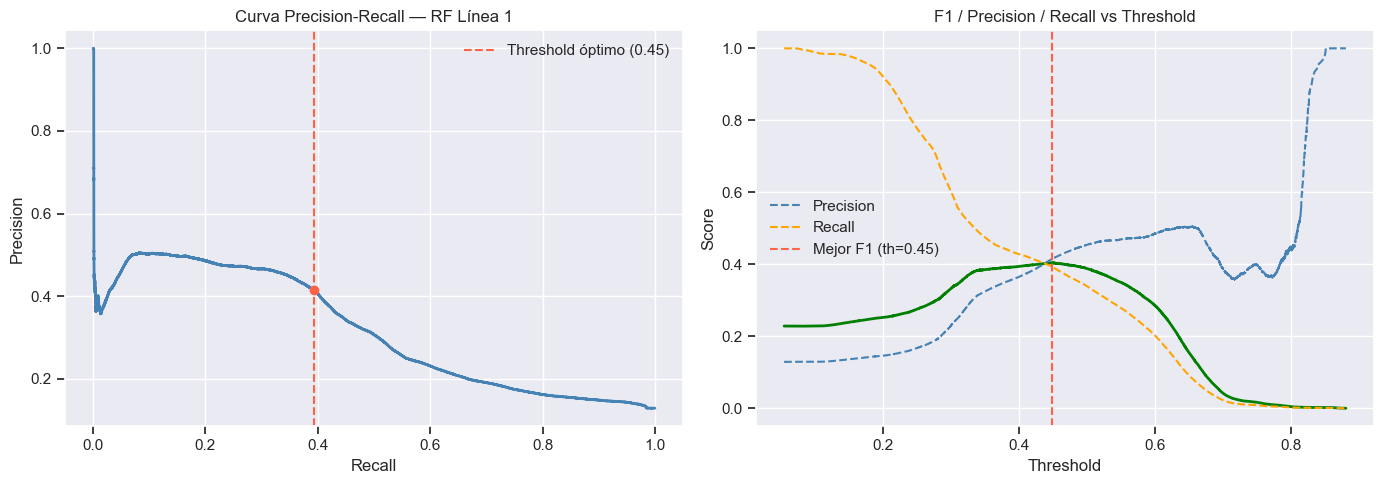


=== Resultados con threshold óptimo ===
              precision    recall  f1-score   support

      Normal       0.91      0.92      0.91    608989
  Pre-alerta       0.42      0.39      0.40     90124

    accuracy                           0.85    699113
   macro avg       0.66      0.66      0.66    699113
weighted avg       0.85      0.85      0.85    699113



In [55]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt
import numpy as np

# Probabilidades del modelo en test
y2_proba_test = rf_l1.predict_proba(X2_test)[:, 1]

# Curva Precision-Recall
precisions, recalls, thresholds = precision_recall_curve(y2_test, y2_proba_test)

# F1 para cada threshold
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f"Threshold óptimo (máx F1): {best_threshold:.3f}")
print(f"  Precision: {precisions[best_idx]:.4f}")
print(f"  Recall:    {recalls[best_idx]:.4f}")
print(f"  F1:        {f1_scores[best_idx]:.4f}")

# Gráfico
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# — Curva PR —
axes[0].plot(recalls, precisions, color='steelblue', lw=2)
axes[0].axvline(recalls[best_idx], color='tomato', linestyle='--', label=f'Threshold óptimo ({best_threshold:.2f})')
axes[0].scatter(recalls[best_idx], precisions[best_idx], color='tomato', zorder=5)
axes[0].set_xlabel("Recall")
axes[0].set_ylabel("Precision")
axes[0].set_title("Curva Precision-Recall — RF Línea 1")
axes[0].legend()
axes[0].grid(True)

# — F1 vs Threshold —
axes[1].plot(thresholds, f1_scores[:-1], color='green', lw=2)
axes[1].plot(thresholds, precisions[:-1], color='steelblue', lw=1.5, linestyle='--', label='Precision')
axes[1].plot(thresholds, recalls[:-1], color='orange', lw=1.5, linestyle='--', label='Recall')
axes[1].axvline(best_threshold, color='tomato', linestyle='--', label=f'Mejor F1 (th={best_threshold:.2f})')
axes[1].set_xlabel("Threshold")
axes[1].set_ylabel("Score")
axes[1].set_title("F1 / Precision / Recall vs Threshold")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

# Evaluación con el threshold óptimo
y2_pred_opt = (y2_proba_test >= best_threshold).astype(int)
print("\n=== Resultados con threshold óptimo ===")
print(classification_report(y2_test, y2_pred_opt, target_names=["Normal", "Pre-alerta"]))

In [57]:
importances_l1 = pd.Series(rf_l1.feature_importances_, index=FEATURE_COLS_L1)
features_relevantes = importances_l1[importances_l1 > 0.02].sort_values(ascending=False)

print(f"Features con importancia > 2%: {len(features_relevantes)} de {len(FEATURE_COLS_L1)}")
print()
for feat, imp in features_relevantes.items():
    print(f"  {feat}: {imp:.4f} ({imp*100:.1f}%)")

FEATURE_COLS_L1_REDUCED = features_relevantes.index.tolist()

Features con importancia > 2%: 8 de 22

  seconds_since_last_alert: 0.5694 (56.9%)
  headway_linea_max: 0.0645 (6.5%)
  hour_sin: 0.0591 (5.9%)
  num_updates: 0.0558 (5.6%)
  headway_linea_mean: 0.0551 (5.5%)
  headway_linea_std: 0.0529 (5.3%)
  dow: 0.0491 (4.9%)
  hour_cos: 0.0432 (4.3%)
